# Study 782 — CEO-Name-Length 📛

*For the curious.* Here's a factor so silly it has to be a joke: **sort stocks by how many letters are in the CEO's surname.** Long the longest surnames, short the shortest, hold it market-neutral. It *cannot* work... so why does the tape hand us a *t*-stat of −3? This notebook is a lesson in how a nonsense signal fools you.

## The setup

40 large caps, each tagged with its CEO's surname length (a **static 2026 snapshot** — we don't track who was CEO when; that's fine here *because the label is meaningless by design*). Sort into terciles, hold **long longest-surname / short shortest-surname**, rebalance monthly. A market with any sense should give a flat, boring zero.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ceo_name_length import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching 40 names + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ch = dt.characteristics()
rets = dt.monthly_returns(prices)
ls = st.long_short_series(rets, ch)
print(f"panel loaded; {rets.shape[0]} monthly cross-sections x {rets.shape[1]} names")


panel loaded; 137 monthly cross-sections x 40 names


## The universe and its surname lengths

In [2]:
pd.DataFrame([(t, s, dt.surname_len(s)) for t, s in dt.UNIVERSE],
             columns=['ticker', 'ceo_surname', 'len']).sort_values('len').reset_index(drop=True)

,ticker,ceo_surname,len
0,AMD,Su,2
1,AAPL,Cook,4
2,ORCL,Catz,4
3,TSLA,Musk,4
4,QCOM,Amon,4
5,TXN,Ilan,4
6,GE,Culp,4
7,ABT,Ford,4
8,JPM,Dimon,5
9,CVX,Wirth,5


## The 'result' — and it looks real

| metric | value |
|---|--:|
| monthly long/short mean | **-0.93%** |
| *t* (n = 137) | **-3.06** |
| annualised | ≈ -11.2%/yr |
| hit rate | 58/137 = 42.3% |

The **shortest**-surname tercile out-earned the longest by ~0.9%/month (+2.33% vs +1.40%). A *t* of −3 would get a real factor published. So... surname length works?

In [3]:
s = st.one_sample_t(ls.values); hr = st.hit_rate(ls.values)
print(f"LS mean={s['mean']*100:+.3f}%/mo  t={s['t']:+.3f}  Sharpe={st.sharpe(ls.values):+.2f}  "
      f"hit {hr['k']}/{hr['n']}={hr['rate']*100:.1f}%")

LS mean=-0.930%/mo  t=-3.058  Sharpe=-0.91  hit 58/137=42.3%


## The reveal: *who* is in each leg

Print the two legs and the illusion collapses — the **short** (shortest-surname) leg is just the megacap-tech winners list.

In [4]:
long_names, short_names = st.leg_masks(ch)
sn = {t: s for t, s in dt.UNIVERSE}
print('SHORT leg (shortest surnames):', [f'{t}/{sn[t]}' for t in sorted(short_names)])
print('LONG  leg (longest  surnames):', [f'{t}/{sn[t]}' for t in sorted(long_names)])

SHORT leg (shortest surnames): ['AAPL/Cook', 'ABT/Ford', 'AMD/Su', 'AMZN/Jassy', 'GE/Culp', 'JNJ/Duato', 'JPM/Dimon', 'NVDA/Huang', 'ORCL/Catz', 'QCOM/Amon', 'TSLA/Musk', 'TXN/Ilan', 'XOM/Woods']
LONG  leg (longest  surnames): ['ADBE/Narayen', 'BAC/Moynihan', 'CAT/Umpleby', 'CMCSA/Roberts', 'CSCO/Robbins', 'GS/Solomon', 'IBM/Krishna', 'MA/Miebach', 'MCD/Kempczinski', 'META/Zuckerberg', 'PEP/Laguarta', 'V/McInerney', 'WMT/McMillon']


## The picture: it's a fixed sector bet, not a signal

The cumulative long/short line just bleeds lower the whole decade — a persistent short-tech / long-value tilt that has nothing to do with orthography.

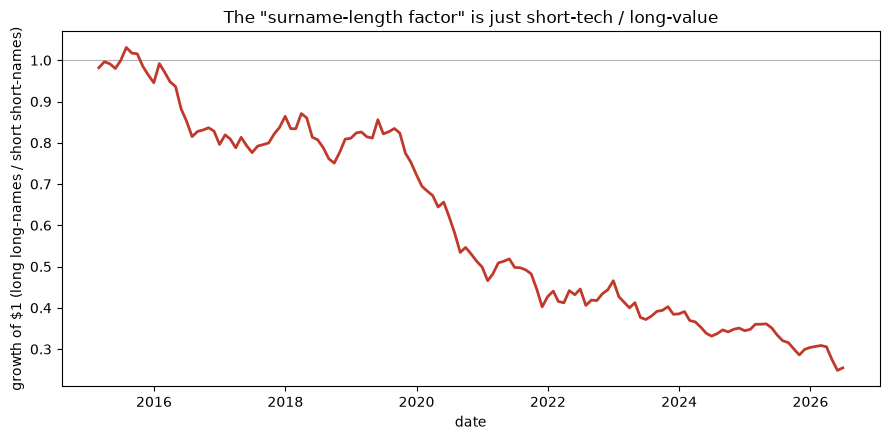

In [5]:
cum = (1 + ls).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axhline(1.0, color='0.7', lw=0.8)
ax.plot(cum.index, cum.values, color='#c0392b', lw=2)
ax.set_ylabel('growth of $1 (long long-names / short short-names)')
ax.set_xlabel('date')
ax.set_title('The "surname-length factor" is just short-tech / long-value')
plt.tight_layout(); plt.show()

## So what?

The number is real; its *cause* is not. Short surnames coincidentally belonged to the megacap-tech cohort (Cook, Jassy, Huang, Musk, Su), so a static 2026 snapshot secretly encodes 'which names became winners.' There's no mechanism, the *t* overstates a single fixed decade-long bet, and the placebo is only borderline (p ≈ 0.04). Verdict: **Weak signal, Mirage tradability** — the classic data-snooping trap. The quants' notebook has the placebo, the jackknife, the costs and the synthetic control.